# ARIM-Academy：　SHAP編

---
### 対象読者・前提知識・動作環境・版とライセンス

- **対象読者**: ARIMデータポータル会員の研究者・技術者。Python の基礎文法は理解しているが、機械学習モデルの解釈手法（XAI）に触れるのは初めての方。
- **前提知識**: pandas の基本操作（DataFrame の読み込み・列選択）、scikit-learn 系ライブラリでの `fit`/`predict` の基本的な流れ。統計学・機械学習の専門的な予備知識は前提としません。
- **動作環境**: Google Colab での実行を想定（`!pip install` セルで xgboost・shap を導入）。ローカル環境で実行する場合は、あらかじめ `pip install xgboost shap` としてください。本編は shap 0.49、xgboost 3.2、scikit-learn 1.7 系での動作を確認しています。
- **版とライセンス**: 本教材は ARIM データポータルの情報活用講座向けに作成したオリジナル教材です。使用データセットは California Housing（出典は本編「データセット」の節を参照）。

---

---
## SHAP（SHapley Additive exPlanations）

SHAPは機械学習モデルの予測を解釈し、個々の特徴量が予測にどの程度寄与しているかを評価するための手法の一つです。SHAP値はゲーム理論において協力によって得られた利得をプレイヤーに分配するアルゴリズムです。このアルゴリズを機械学習分野へ転用することで、特徴量の寄与度を公平かつ一貫性のある方法で評価することができ、説明が可能なAI(XAI）を提供します。

<img src="./img/shap_header.svg" width="70%">

SHAPの主要な概念と要点は以下の通りです：

1. シャプリー値（Shapley Values）: シャプリー値はゲーム理論から派生した概念で、特徴量が予測にどれだけ寄与するかを評価するために使用されます。シャプリー値は、特徴量の組み合わせごとに計算され、その特徴量がどれだけ貢献したかを示します。このアプローチは、特徴量の寄与を公平に評価するために使用され、全ての特徴量が協力して予測に寄与する場合に特に役立ちます。

2. 予測の解釈: SHAPを使用することで、モデルの予測がどの特徴量にどの程度依存しているかを可視化できます。これにより、モデルの予測が理解しやすくなり、特徴量の重要性を定量化できます。

3. Tree SHAP: SHAP値の計算は、特にツリーベースのモデル（例: ランダムフォレスト、勾配ブースティングなど）に対して効率的に行うためのアルゴリズムがあります。Tree SHAPアルゴリズムは、特徴量の組み合わせを効率的に評価し、SHAP値を計算します。

4. モデルの説明性の向上: SHAPは、モデルの予測をより解釈可能にし、モデルの予測が不正確な場合やバイアスがある場合にその原因を特定するのに役立ちます。また、特徴量の寄与を評価することで、モデルの改善や特徴量の選択に関する意思決定を支援します。
---

## データセット
"California Housing" は、アメリカ・カリフォルニア州の住宅価格に関するデータを収集したデータセットです。このデータセットは、機械学習やデータ分析の教育や研究でよく使用され、住宅価格を予測するためのモデルを構築する際に役立ちます。

California Housingデータセットには、住宅価格（目的変数）を予測するための8種類の説明変数（特徴量）と、1つの目的変数があります。

**説明変数（特徴量）**

1. **MedInc**: 地域内の家計の収入（中央値）。  世帯収入の指標となります。
1. **HouseAge** : 地域内の住宅の築年数（中央値）。住宅がどれくらい古いかを示す指標です。
1. **AveRooms**: 平均部屋数。地域内の住宅の平均部屋数を示しています。
1. **AveBedrms**: 平均寝室数。地域内の住宅の平均寝室数を示しています。
1. **Population**: 地域内の総人口。
1. **AveOccup**: 平均住戸数。地域内の住宅の平均住戸数を示しています。
1. **Latitude**: 地域内の緯度。
1. **Longitude**: 地域の経度。

**目的変数**

- **MedHouseVal**: 地域内の住宅価格の中央値。本編ではこれを予測するモデルを構築します。

# 教材への接続
google colabにおけるオンラインの場合にこのラインを実行します。（Google colabに接続しない場合には不要）

In [ ]:
!pip install xgboost
!pip install shap
! pip install matplotlib_fontja
!git clone https://github.com/ARIM-ACADEMY-2026/Advanced_Tutorial_4_Chemoinformatics.git
%cd Advanced_Tutorial_4_Chemoinformatics

### ライブラリのインポート

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import xgboost
import shap

# 警告を無視
from warnings import filterwarnings
filterwarnings('ignore')

### サンプルファイルの読み込み
shapライブラリにセットされている"California Housing" データセットを読み込みます。サンプル数（標本数）は20640であることが確認できます。

In [2]:
X, y = shap.datasets.california()

In [3]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


### SHAPのによる特徴量の評価・可視化方法の流れ

#### shapライブラリについて： https://github.com/shap/shap   
Shapライブラリは、機械学習モデルの解釈性を向上させるためのSHAP計算や、その評価を行うことができるツール群です。ツリーアンサンブル法（例: ランダムフォレスト、勾配ブースティングなど）の視点から個々の予測を解釈し、各特徴量の寄与を示すForce PlotやSummary Plotなどの可視化ツールを提供します。

`shap` を使用する一般的な手順は次の通りです:

1. **モデル構築**：　scikit-learnなどを用いて機械学習モデル（ＭＬモデル）を構築します。
2. **Explainerの設定**：　ＭＬモデルとデータを `shap.Explainer()` に渡します。
3. **SHAP値の計算**：　`Explainer` オブジェクトを使用して SHAP 値（shap_values）を計算します。
4. **評価（可視化）**：　その後にbeeswarm plotやforce plotで可視化します。

### 1. モデル構築（XGboost）
MLモデルでは、XGBoost（Extreme Gradient Boosting）で評価する例で進めてゆきます。XGBoostは、機械学習モデルの一つで、勾配ブースティングアルゴリズムを基にした強力なアンサンブル学習手法で高い性能と汎化能力を持つことで知られ、様々なデータ科学のタスクで広く使用されています。

XGBoostに特化したxgboostライブラリを読み込みますが、その後のインスタンス化やモデルFitの流れはScikit-learnの手続きとかわりません。

【注意】本編の目的は「SHAPによる特徴量の解釈」の手順を体験することにあるため、`2_descriptor-paper2.ipynb`・`3_morgan paper2.ipynb` のような訓練データ・テストデータへの分割は行わず、データ全体でモデルを学習させています。そのため、ここで作成するモデルの予測精度そのもの（汎化性能）は評価していません。モデルの精度を検証する場合は、他編と同様に `train_test_split()` で訓練・テストデータに分けてください。

なお、`XGBRegressor()` はデフォルト設定（`subsample=1.0` など）ではブートストラップ抽出を行わないため、CPU環境では基本的に実行のたびに同じ結果が得られます。ただし、マルチスレッドでの浮動小数点演算順序により、環境によってはごくわずかな差異が生じる場合があります。

In [4]:
model = xgboost.XGBRegressor()
model.fit(X, y)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### 2. Explainerの設定

In [5]:
%%time
exp = shap.TreeExplainer(model)

CPU times: total: 203 ms
Wall time: 95.5 ms


【解説】　**TreeExplainer** について
`shap.TreeExplainer()` は、`shap.Explainer()` が提供する複数のアルゴリズムの中でも、決定木ベースのモデル（Random Forest・XGBoost・LightGBM など）専用に最適化された Explainer です。前セルの「1. Tree SHAP」で触れた Tree SHAP アルゴリズムを使い、木の分岐構造を利用してSHAP値を高速かつ厳密に計算します。木ベース以外のモデル（線形モデル・ニューラルネットなど）には使えないため、モデルの種類に応じて `shap.Explainer()`（自動選択）または `LinearExplainer`・`DeepExplainer` など専用クラスを使い分けます。

```
explainer = shap.TreeExplainer(model, data=None, **kwargs)
```
のように初期化されます。

主なパラメータと引数:

1. `model`: SHAP 値を計算するための木ベースの機械学習モデルです。このモデルは、Python の機械学習ライブラリ（例: scikit-learn、XGBoost、LightGBM）でトレーニングされたものである必要があります。

2. `data` (オプション): データセットを指定します。このデータセットは、モデルのトレーニング時と同じ特徴量を持つ必要があります。指定しない場合、モデルの木構造から直接期待値を計算します（本編ではこちらの方式を使用）。

3. `**kwargs` (オプション): Explainer クラスの初期化に関する他のオプションやパラメータを指定します。具体的なオプションはライブラリのバージョンによって異なることがあります。

なお、`shap.Explainer(model)` のように汎用クラスを呼び出しても、モデルが木ベースであれば SHAP ライブラリが自動的に Tree SHAP を選択するため、内部的には同じ計算になります。


### 3. SHAP値の計算
Explainerにデータ（ここでは教師データX）を渡します。

In [6]:
shap_values = exp(X)

### 4. 可視化と評価

**（図1）**
### 4.1 bar plot
各特徴のSHAP値の平均絶対値を取るだけで、標準棒グラフが得られます（マルチクラス出力では積み重ね棒グラフが得られます）。
バープロットではバーの高さが特徴量の重要性を示し、高いバーは予測に対して重要な特徴量を示します。

### Global bar plot

SHAP値のマトリックスを`plots.bar()`関数に渡すと、大域的な特徴量の重要度プロットが作成されます。各特徴の大域的な重要度は、与えられたすべてのサンプルにわたるその特徴量の平均絶対値とみなされます。

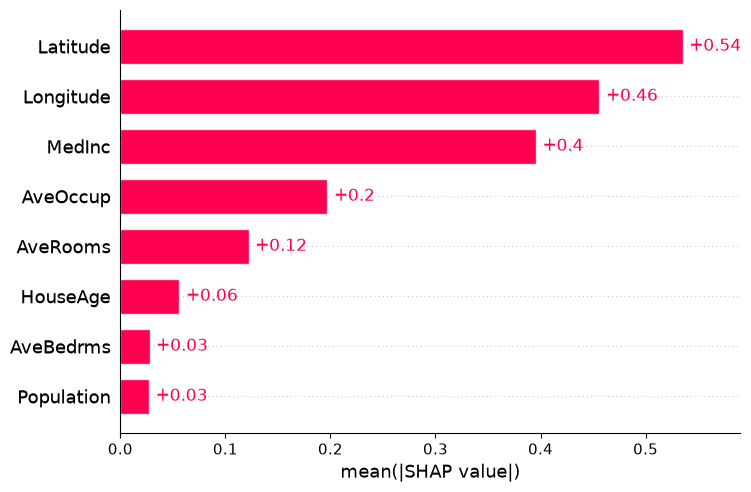

In [7]:
shap.plots.bar(shap_values)

デフォルトでは、棒グラフは10本表示されますが、表示数は`max_display`パラメータで制御できます。

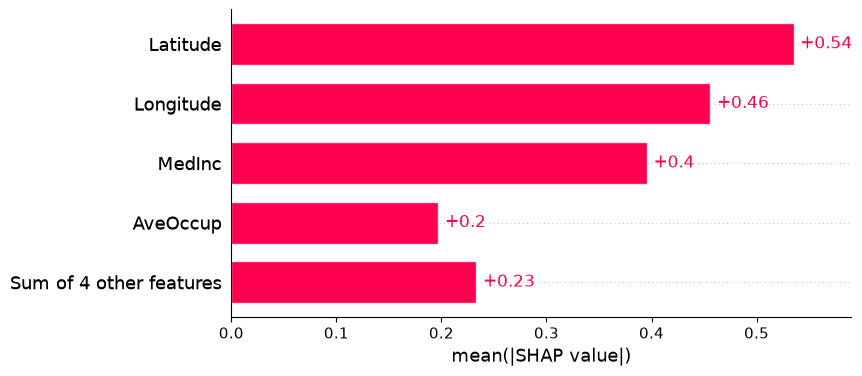

In [8]:
shap.plots.bar(shap_values, 
               max_display=5
              )

### Local bar plot

各インスタンス（サンプル）のSHAP値を`plots.bar()`関数に渡すと、各特徴量のSHAP値を棒グラフにしたサンプルごとの特徴量の重要度プロットが作成されます。なお、特徴量の値は特徴量名の左側にグレーで表示されます。

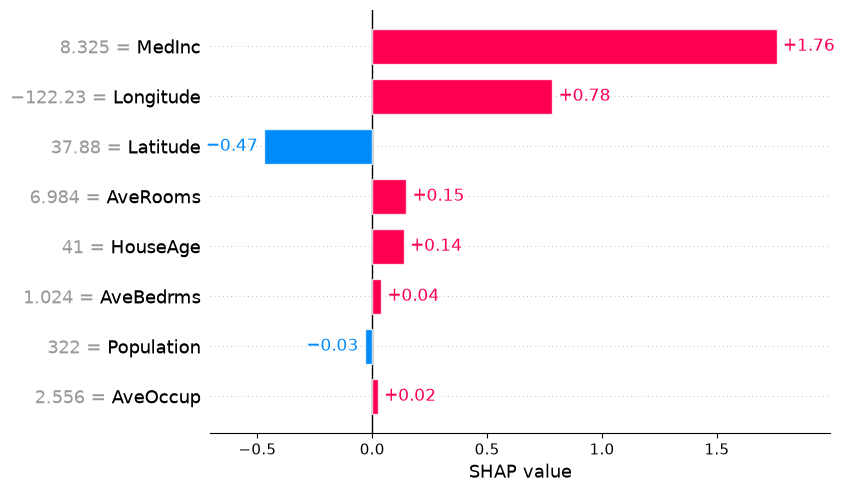

In [9]:
#　最初のインスタンス（サンプル）のSHAP値
shap.plots.bar(shap_values[0])

### 4.2 beeswarm plot

**（図2）**

ビースワームプロットでは、各特徴量のSHAP値が水平に散布され、各点はデータセット内の特定のデータポイントを表します。プロット内の点の分布は、特徴量のSHAP値の分布を示し、各特徴量が予測にどの程度影響を与えているかを示します。

shapの可視化法では、最もポピュラーな表現図です。

### simple beeswarm summary plot
下のプロットは、全サンプルのSHAP値の大きさの合計で特徴をソートし、SHAP値を使って各特徴がモデル出力に与える影響の分布を示します。
色は特徴値を表しています（赤が高く、青が低い）。これにより、例えば世帯所得（MedInc）が高いほど住宅価格（予測値）は高まることがわかります。

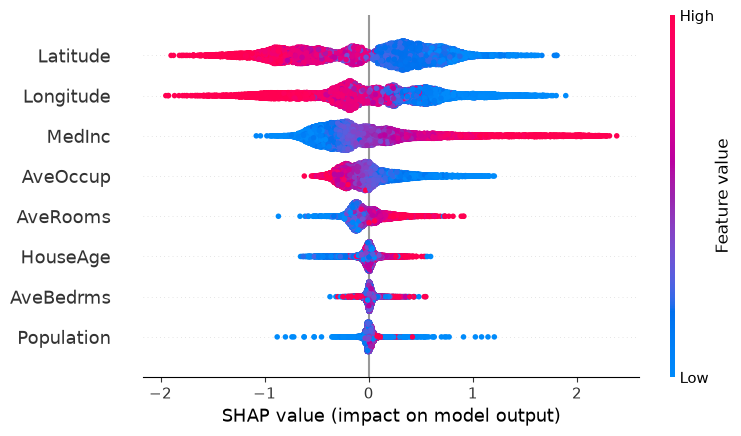

In [10]:
# summarize the effects of all the features
shap.plots.beeswarm(shap_values)

### Feature ordering

デフォルトでは、各特徴量の SHAP 値の絶対値の平均値である shap_values.abs.mean(0) を用いて並べています。しかし、この順序は大まかな平均のImpactが重視されるため、稀ではありますが、大きなImpact影響が重視れないことがあります。このようなとき、代わりに絶対値の最大値でソートすることができます。

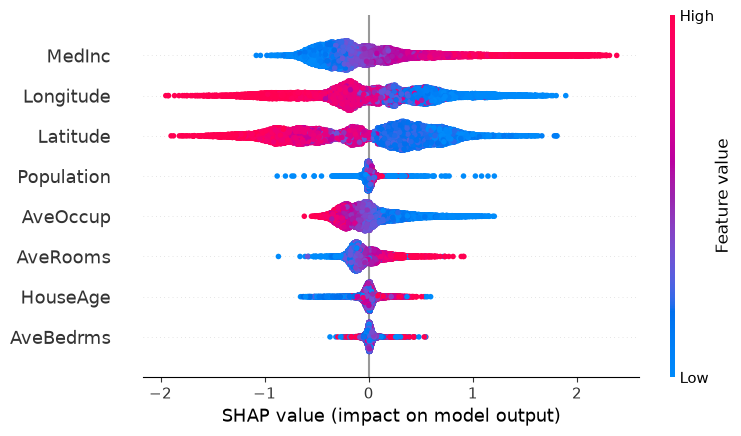

In [11]:
shap.plots.beeswarm(shap_values, 
                    order = shap_values.abs.max(0)
                   )

### 色のカスタマイズ化

デフォルトでは、beeswarmはshap.plots.colors.red_blueカラーマップを使用しますが、colorパラメータを使用して任意のmatplotlibカラーまたはカラーマップに変更することができます。

【matplotlibのカラーマップ】　https://matplotlib.org/stable/users/explain/colors/colormaps.html

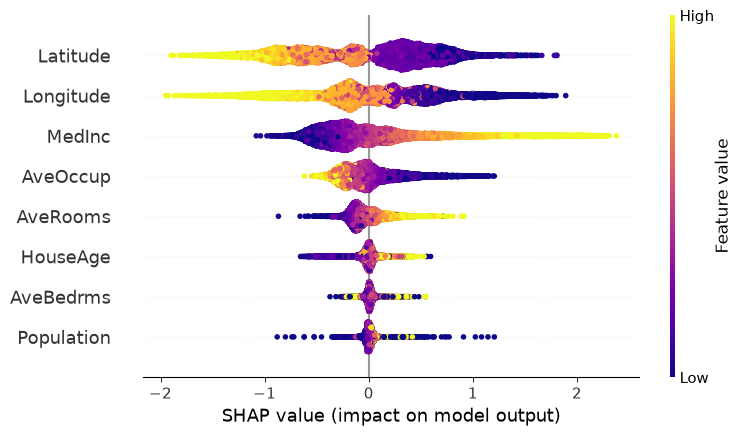

In [12]:
shap.plots.beeswarm(shap_values, 
                    color=plt.get_cmap("plasma")
                   )

### 4.3 waterfall plot

**（図3）**
waterfallプロットは、モデルの予測を理解し、個々のデータポイントに対する予測の詳細を調査するのに役立ちます。特に、どの特徴量が特定の予測にどの程度影響を与えているかを視覚的に理解できます。

各特徴が基本値（渡したトレーニングデータセットの平均モデル出力）からモデル出力を押し上げるのに貢献していることを示しています。  予測値を押し上げる特徴量は赤で、予測値を押し下げる特徴量は青で示されています。 プロットの下部には、全体の予測（E[f(x)]）と各特徴量の寄与の合計が表示されます。

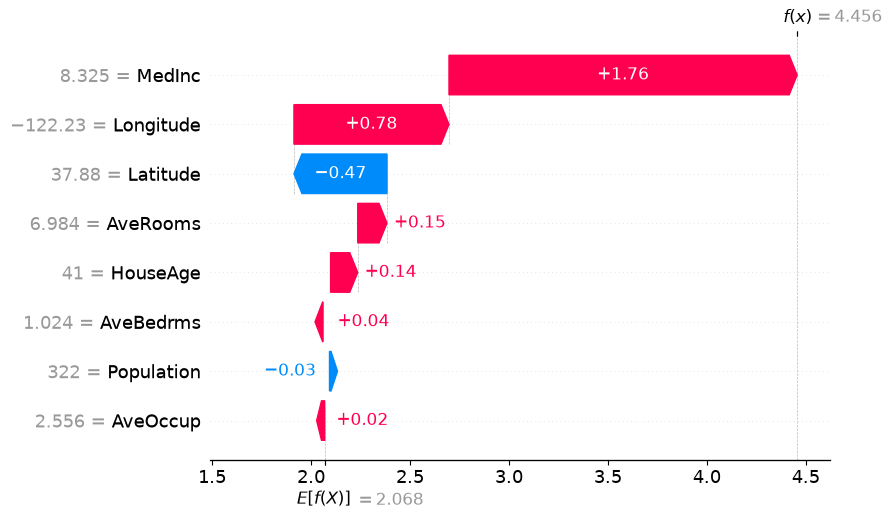

In [13]:
# visualize the first prediction's explanation
shap.plots.waterfall(shap_values[0])

### 4.4 force plot

**（図4）**
同じ説明を視覚化する別の方法としては、force plotを使うことができます。Force プロットは、特定のデータポイントに対する予測を詳細に解釈するための寄与度を視覚化します。  

プロット内には以下の情報が含まれます：

* Base Value（E[f(x)]）: 予測の基準値。訓練データ全体に対するモデル予測の平均値で、waterfall plot の「Base Value」と同じものです。
* Output Value（f(x)）: そのデータポイントに対する実際のモデル予測値。
* Feature Contributions: 各特徴量のSHAP値。Base Value から Output Value へ至る差分の内訳を表し、正の寄与は赤、負の寄与は青で示されます。

In [14]:
# visualize the first prediction's explanation with a force plot
shap.initjs()
shap.plots.force(shap_values[0])

上図のフォース・プロットをたくさん取り出して90度回転させ、水平に積み重ねると、データセット全体の説明を見ることができます。下記は500番目までのサンプル（インスタンス）を縦に並べた表示例です。
（JupyterNotebookでは、このプロットはインタラクティブになっています）

In [15]:
# visualize all the training set predictions
shap.initjs()
shap.plots.force(shap_values[:500])

### 4.5 scatter plot

**（図5）**
Scatter プロットでは、2つの特徴量に関連するSHAP値が表示されます。各点はデータセット内の特定のデータポイントを表し、x軸とy軸にはそれぞれ異なる特徴量のSHAP値が表示されます。プロット内の各点は、特定のデータポイントの予測に対する2つの特徴量の寄与を示します。点の位置が x 軸上で右に寄っている場合、その特徴量は予測を増加させる方向に寄与し、左に寄っている場合は予測を減少させる方向に寄与します。

SHAP値はモデル出力の変化に対する特徴量の寄与を表すので、下のプロットは、緯度の変化に伴う住宅価格の予測値の変化を表しています。

緯度（Latitude）の1つの値での垂直方向の分散は、他の特徴との相互作用効果を表します。これらの相互作用を明らかにするのを助けるために、別の特徴で色を付けることができます。
説明テンソル全体をcolor引数に渡すと、散布図は色付けするのに最適な特徴を選びますが、この場合は経度を選んでいます。

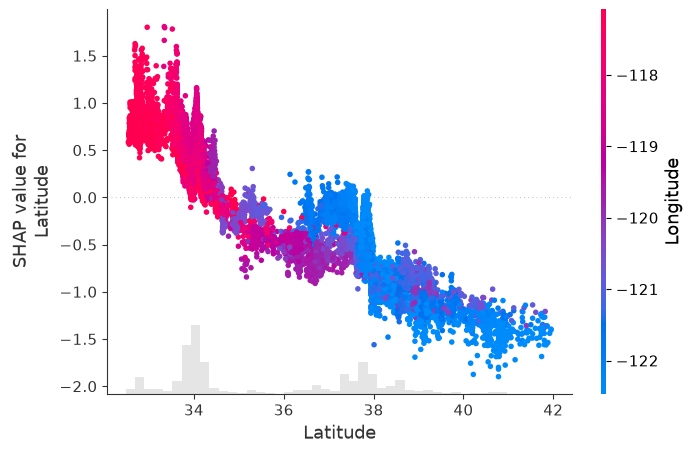

In [16]:
# create a dependence scatter plot to show the effect of a single feature across the whole dataset

shap.plots.scatter(shap_values[:, "Latitude"], 
                   color=shap_values
                  )

---
## まとめ

本編では、California Housing データセットと XGBoost 回帰モデルを題材に、SHAP（SHapley Additive exPlanations）を使ったモデル解釈の一連の流れを体験しました。

- `shap.TreeExplainer()` で木ベースモデル専用の Explainer を作成し、`shap_values` を計算する手順
- bar plot（大域的な重要度）・beeswarm plot（分布を伴う大域的な重要度）・waterfall plot / force plot（個々の予測の内訳）・scatter plot（特徴量間の相互作用）という、目的に応じた可視化の使い分け
- 図1・図2の bar plot と beeswarm plot からは、世帯収入（MedInc）や地域（Latitude・Longitude）が住宅価格予測に対して特に大きな寄与を持つことが確認できました

## 本編で扱っていないこと（今後の課題）

- 訓練データ・テストデータへの分割によるモデルの汎化性能評価（本編は解釈手法の体験が目的のため未実施）
- 分類タスクにおけるSHAPの利用（本編は回帰タスクのみ）
- `LinearExplainer`・`KernelExplainer` など、木ベース以外のモデルに対応するExplainerの使い方
- `2_descriptor-paper2.ipynb`・`3_morgan paper2.ipynb` で扱う、化学構造データ（分子記述子・フィンガープリント）へのSHAP適用

## 演習問題

1. `shap.plots.bar(shap_values, max_display=...)` の `max_display` の値を変えて、上位何位までの特徴量が住宅価格予測に強く影響しているか確認してください。
2. `shap.plots.scatter()` の対象特徴量を `"Latitude"` から `"MedInc"` に変更し、世帯収入とSHAP値の関係がどのような形状になるか観察してください。
3. 本編のモデルに `train_test_split()` を追加し、テストデータに対するSHAP値の傾向が訓練データと大きく変わらないか確認してください。
